Modéle computer vision : EfficientNet

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Contenu train : ['train']
Contenu test  : ['test']

Fichier train utilisé : /content/drive/MyDrive/CV_dataset/train/train
Fichier test  utilisé : /content/drive/MyDrive/CV_dataset/test/test

Clés dans train : [b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data']
Clés dans test  : [b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data']

Exemple de classes : ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']

✅ Dataset chargé avec succès !
  X_train : (50000, 32, 32, 3)  |  y_train : (50000,)
  X_test  : (10000, 32, 32, 3)   |  y_test  : (10000,)
  Valeurs X_train → min: 0.00, max: 1.00
  Nombre de classes : 100


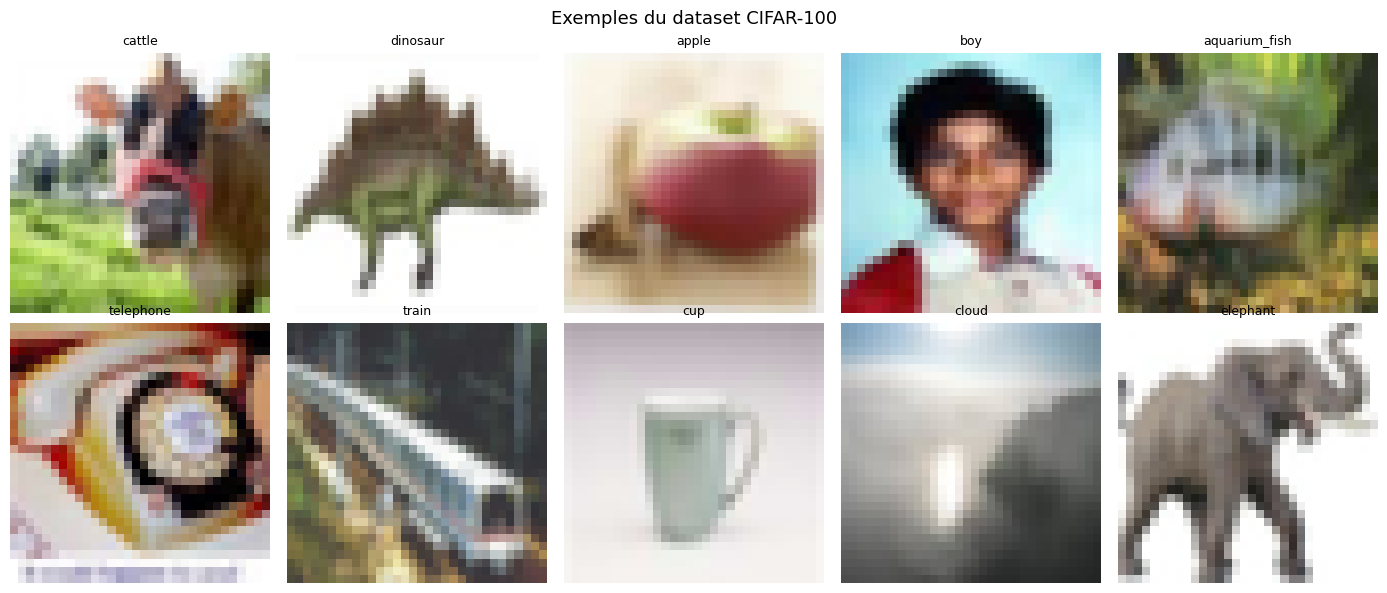

In [2]:


# ============================================================
# 2. Imports
# ============================================================
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 3. Trouver le fichier pickle dans le dossier
# ============================================================
train_dir = '/content/drive/MyDrive/CV_dataset/train'
test_dir  = '/content/drive/MyDrive/CV_dataset/test'

# Afficher le contenu pour identifier le nom exact du fichier
print("Contenu train :", os.listdir(train_dir))
print("Contenu test  :", os.listdir(test_dir))

# Prendre automatiquement le premier fichier trouvé dans chaque dossier
train_file = os.path.join(train_dir, os.listdir(train_dir)[0])
test_file  = os.path.join(test_dir,  os.listdir(test_dir)[0])

print("\nFichier train utilisé :", train_file)
print("Fichier test  utilisé :", test_file)

# ============================================================
# 4. Charger les fichiers pickle
# ============================================================
def load_data(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

train_data = load_data(train_file)
test_data  = load_data(test_file)

# Afficher les clés disponibles pour vérification
print("\nClés dans train :", list(train_data.keys()))
print("Clés dans test  :", list(test_data.keys()))

# ============================================================
# 5. Extraire X et y
# ============================================================
X_train = train_data[b'data']
y_train = np.array(train_data[b'fine_labels'])   # 100 classes → fine_labels

X_test  = test_data[b'data']
y_test  = np.array(test_data[b'fine_labels'])

# ============================================================
# 6. Preprocessing : reshape + normalisation
# ============================================================
def preprocess(X):
    X = X.reshape(-1, 3, 32, 32)       # (N, 3072) → (N, 3, 32, 32)
    X = np.transpose(X, (0, 2, 3, 1))  # (N, 3, 32, 32) → (N, 32, 32, 3)
    X = X / 255.0                       # normalisation [0, 1]
    return X

X_train = preprocess(X_train)
X_test  = preprocess(X_test)

# ============================================================
# 7. Charger les noms des 100 classes (optionnel mais utile)
# ============================================================
meta_dir  = '/content/drive/MyDrive/CV_dataset'
meta_files = [f for f in os.listdir(meta_dir) if 'meta' in f.lower()]

if meta_files :
    meta = load_data(os.path.join(meta_dir, meta_files[0]))
    class_names = [c.decode('utf-8') for c in meta[b'fine_label_names']]
    print("\nExemple de classes :", class_names[:10])
else:
    class_names = [str(i) for i in range(100)]
    print("\nFichier meta non trouvé, classes nommées 0-99")

# ============================================================
# 8. Résumé final
# ============================================================
print("\n✅ Dataset chargé avec succès !")
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"  Valeurs X_train → min: {X_train.min():.2f}, max: {X_train.max():.2f}")
print(f"  Nombre de classes : {len(np.unique(y_train))}")

# ============================================================
# 9. Visualiser quelques images (optionnel)
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Exemples du dataset CIFAR-100", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# ============================================
# 1. Choisir 20 classes parmi les 100
# ============================================
# Vous pouvez changer ces numéros selon les classes qui vous intéressent
CLASSES_CHOISIES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                    10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

# ============================================
# 2. Filtrer train
# ============================================
mask_train = np.isin(y_train, CLASSES_CHOISIES)
X_train_20 = X_train[mask_train]
y_train_20 = y_train[mask_train]

# ============================================
# 3. Filtrer test
# ============================================
mask_test = np.isin(y_test, CLASSES_CHOISIES)
X_test_20 = X_test[mask_test]
y_test_20  = y_test[mask_test]

# ============================================
# 4. Remapper les labels 0→19 (obligatoire)
#    ex: classe 5 → 0, classe 10 → 1, etc.
# ============================================
label_map = {old: new for new, old in enumerate(CLASSES_CHOISIES)}

y_train_20 = np.array([label_map[y] for y in y_train_20])
y_test_20  = np.array([label_map[y] for y in y_test_20])

In [20]:
from sklearn.model_selection import train_test_split

x_val_20, x_test_20, y_val_20, y_test_20 = train_test_split(X_test_20, y_test_20, test_size=0.5)

In [21]:
# 4. Créer les générateurs de données (avec redimensionnement et normalisation)
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.model_selection import train_test_split  # si besoin
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import DenseNet121, EfficientNetV2S
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [22]:
# Encoder y en one-hot (nécessaire pour categorical_crossentropy)
NUM_CLASSES = len(np.unique(y_test_20))
y_train_cat = to_categorical(y_train_20, NUM_CLASSES)
y_test_cat  = to_categorical(y_test_20,  NUM_CLASSES)
y_val_cat  = to_categorical(y_val_20,  NUM_CLASSES)

In [ ]:
# ============================================
# Data Augmentation
# ============================================
#data_augmentation = models.Sequential([
#    layers.RandomFlip("horizontal"),
#    layers.RandomRotation(0.15),
#    layers.RandomZoom(0.15),
#    layers.RandomTranslation(0.1, 0.1),
#    layers.RandomContrast(0.1),
#], name="augmentation")

In [33]:
# ============================================
# Modèle EfficientNetV2-S
# ============================================
base_model = EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_preprocessing=True  # prétraitement intégré, pas besoin de preprocess_input
)
base_model.trainable = False

inputs  = layers.Input(shape=(32, 32, 3))
x       = layers.Resizing(224, 224)(inputs)
#x       = data_augmentation(x)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [34]:
# ============================================
# Callbacks
# ============================================
#callbacks = [
#    EarlyStopping(monitor='val_loss', patience=7,
#                  restore_best_weights=True, verbose=1),
#    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
#                      patience=3, min_lr=1e-7, verbose=1)
#]

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1)
]

In [25]:
# ============================================
# IMPORTANT : reconvertir [0,1] → [0,255]
# car EfficientNetV2 gère sa propre normalisation
# ============================================
X_train_255 = (X_train_20 * 255.0).astype('float32')
X_test_255  = (X_test_20  * 255.0).astype('float32')
x_val_255  = (x_val_20  * 255.0).astype('float32')

In [35]:
# ============================================
# Phase 1 : tête seulement (LR élevé)
# ============================================
model.compile(
    optimizer=optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    X_train_255, y_train_cat,
    batch_size=64,
    epochs=13,
    validation_data=(x_val_255, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/13
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 505ms/step - accuracy: 0.8091 - loss: 4.9423 - val_accuracy: 0.8820 - val_loss: 2.4531 - learning_rate: 0.0010
Epoch 2/13
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 217ms/step - accuracy: 0.8737 - loss: 1.4817 - val_accuracy: 0.8860 - val_loss: 1.0452 - learning_rate: 0.0010
Epoch 3/13
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 206ms/step - accuracy: 0.8813 - loss: 0.9061 - val_accuracy: 0.8790 - val_loss: 0.8657 - learning_rate: 0.0010
Epoch 4/13
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 202ms/step - accuracy: 0.8727 - loss: 0.8654 - val_accuracy: 0.8940 - val_loss: 0.8671 - learning_rate: 0.0010
Epoch 5/13
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 207ms/step - accuracy: 0.8747 - loss: 0.8796 - val_accuracy: 0.8730 - val_loss: 0.8927 - learning_rate: 0.0010
Epoch 6/13
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8850 - loss: 0.8489
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - accuracy: 0.87

In [36]:
# ============================================
# Résultat final
# ============================================

loss, acc = model.evaluate(x_val_255, y_val_cat, verbose=0)
print(f"✅ Accuracy finale : {acc*100:.2f}%")

loss, acc = model.evaluate(x_val_255, y_val_cat, verbose=0)
print(f"✅ Accuracy finale : {acc*100:.2f}%")

✅ Accuracy finale : 89.80%


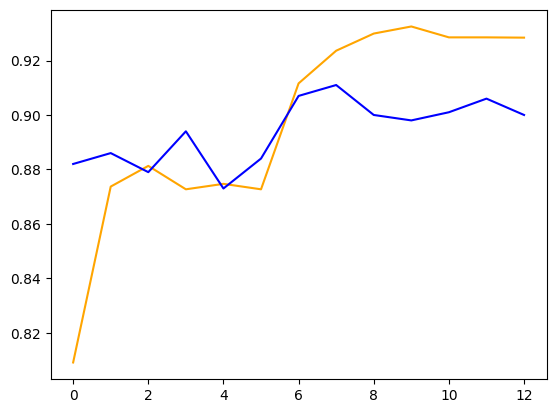

In [38]:
plt.plot(history1.history['accuracy'], c='orange')
plt.plot(history1.history['val_accuracy'], c='blue')

plt.show()

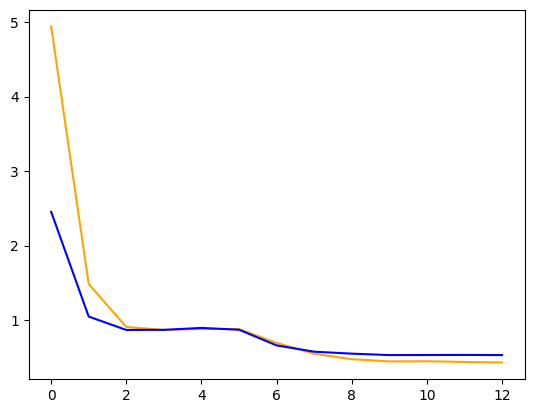

In [39]:
plt.plot(history1.history['loss'], c='orange')
plt.plot(history1.history['val_loss'], c='blue')

plt.show()

⏳ Prédictions en cours...
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step

🎯 Accuracy sur validation : 89.80%


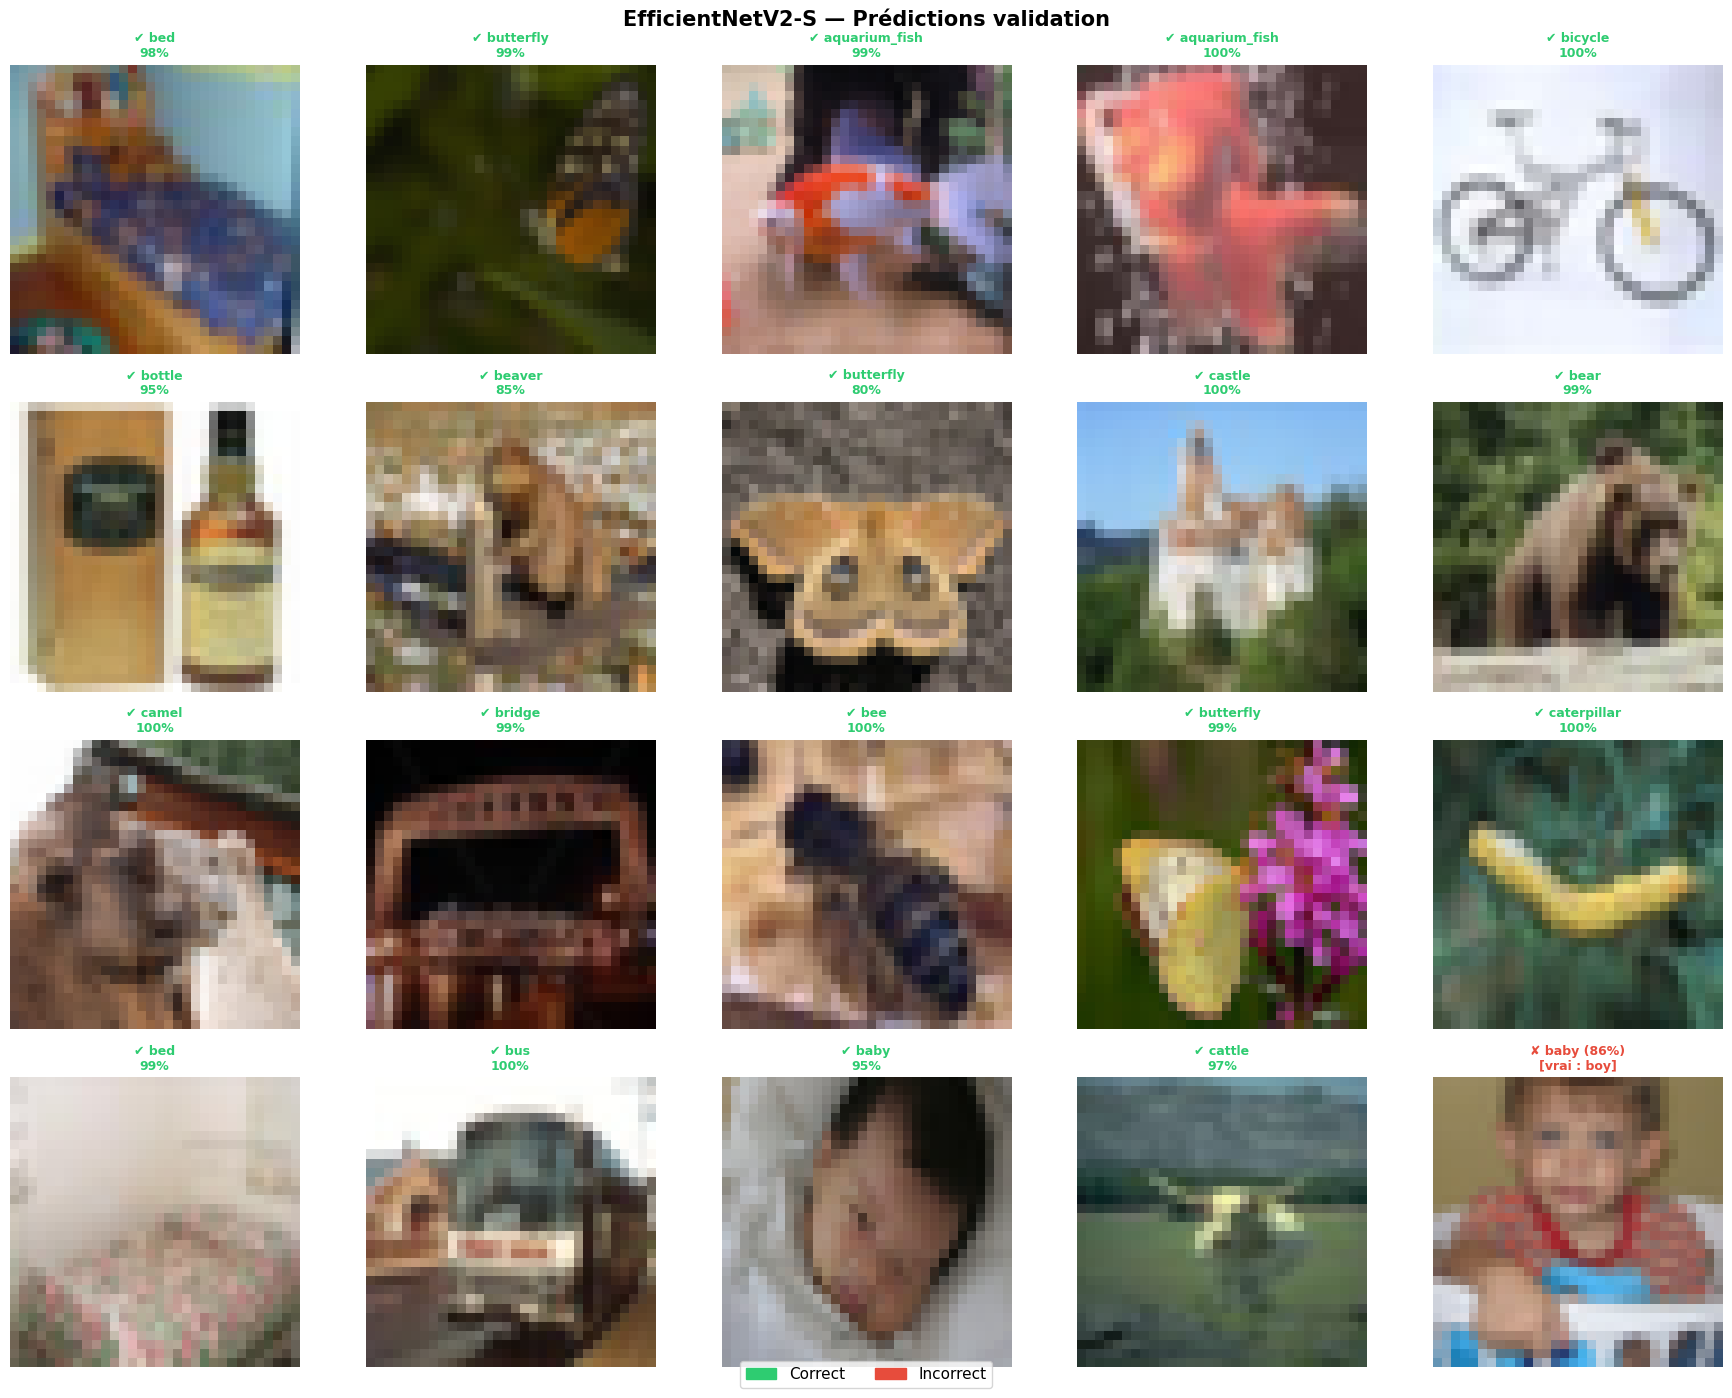


❌ Top 10 confusions (vrai → prédit) :
Vraie classe         Prédite comme           Nb
-----------------------------------------------
baby                 boy                      6
boy                  baby                     6
bear                 beaver                   4
beaver               bear                     4
cattle               camel                    3
bear                 cattle                   2
bee                  beetle                   2
butterfly            caterpillar              2
bowl                 can                      2
bowl                 bottle                   2

📊 Accuracy par classe :
Classe                Correct    Total   Accuracy
------------------------------------------------
apple                      46       47      97.9%
aquarium_fish              53       60      88.3%
baby                       38       50      76.0%
bear                       44       53      83.0%
beaver                     41       49      83.7%
bed        

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# ============================================
# 1. Prédictions
# ============================================
# x_val_255 et y_val_cat sont déjà définis dans ton code
print("⏳ Prédictions en cours...")
y_pred_proba = model.predict(x_val_255, batch_size=64, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)   # classe prédite (int)
y_true       = np.argmax(y_val_cat,    axis=1)   # vraie classe   (int)

# ============================================
# 2. Accuracy globale
# ============================================
accuracy = np.mean(y_pred == y_true)
print(f"\n🎯 Accuracy sur validation : {accuracy*100:.2f}%")

# ============================================
# 3. Noms des classes
# ============================================
CLASSES_CHOISIES = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]
selected_names   = [class_names[i] for i in CLASSES_CHOISIES]

# ============================================
# 4. Visualisation 20 images
# ============================================
n_show  = 20
indices = np.random.choice(len(x_val_255), n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle("EfficientNetV2-S — Prédictions validation", fontsize=15, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    img      = x_val_255[idx].astype(np.uint8)   # [0,255] → affichage direct
    true_lbl = selected_names[y_true[idx]]
    pred_lbl = selected_names[y_pred[idx]]
    conf     = y_pred_proba[idx][y_pred[idx]] * 100
    correct  = (y_true[idx] == y_pred[idx])

    ax.imshow(img)
    ax.axis('off')

    color = '#2ecc71' if correct else '#e74c3c'
    titre = f"✔ {pred_lbl}\n{conf:.0f}%" if correct else f"✘ {pred_lbl} ({conf:.0f}%)\n[vrai : {true_lbl}]"
    ax.set_title(titre, fontsize=9, color=color, fontweight='bold')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

legend = [mpatches.Patch(color='#2ecc71', label='Correct'),
          mpatches.Patch(color='#e74c3c', label='Incorrect')]
fig.legend(handles=legend, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/predictions_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. Top-10 confusions
# ============================================
errors_idx  = np.where(y_pred != y_true)[0]
error_pairs = [(selected_names[y_true[i]], selected_names[y_pred[i]]) for i in errors_idx]
top_errors  = Counter(error_pairs).most_common(10)

print(f"\n❌ Top 10 confusions (vrai → prédit) :")
print(f"{'Vraie classe':<20} {'Prédite comme':<20} {'Nb':>5}")
print("-" * 47)
for (true, pred), count in top_errors:
    print(f"{true:<20} {pred:<20} {count:>5}")

# ============================================
# 6. Accuracy par classe
# ============================================
print(f"\n📊 Accuracy par classe :")
print(f"{'Classe':<20} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 48)
for i, name in enumerate(selected_names):
    mask    = y_true == i
    correct = np.sum(y_pred[mask] == i)
    total   = np.sum(mask)
    acc     = correct / total * 100 if total > 0 else 0
    print(f"{name:<20} {correct:>8} {total:>8} {acc:>9.1f}%")